In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]

src_dir = project_root

sys.path.append(str(src_dir))

print(src_dir)

/Users/isaacirwin/Desktop/gsp-finance/src/gsp_finance


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from graphs.laplacian import combinatorial_laplacian
from gsp.fourier import (
    dirichlet_energy,
    graph_fourier_transform,
    inverse_graph_fourier_transform,
)


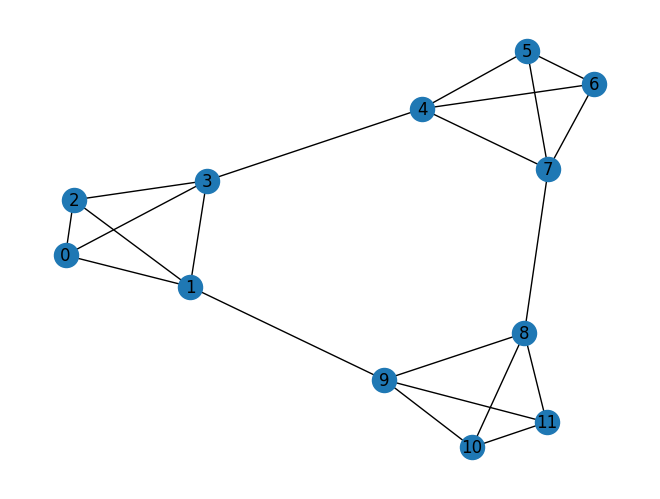

In [5]:
G = nx.Graph()
# Community 1
G.add_edges_from([
    (0,1),(1,3),(3,2),(2,0),(0,3),(1,2)
])
# Community 2
G.add_edges_from([
    (4,5),(5,7),(7,6),(6,4),(4,7),(5,6)
])
# Community 3
G.add_edges_from([
    (8,9),(9,11),(11,10),(10,8),(8,11),(9,10)
])
# Weak inter-community edges
G.add_edge(3,4)
G.add_edge(7,8)
G.add_edge(1,9)
nx.draw(G, with_labels=True)
plt.show()

In [6]:
A = nx.adjacency_matrix(G).todense()
L = combinatorial_laplacian(A)
print("Laplacian:\n", L)

Laplacian:
 [[ 3 -1 -1 -1  0  0  0  0  0  0  0  0]
 [-1  4 -1 -1  0  0  0  0  0 -1  0  0]
 [-1 -1  4 -1 -1  0  0  0  0  0  0  0]
 [-1 -1 -1  3  0  0  0  0  0  0  0  0]
 [ 0  0 -1  0  4 -1 -1 -1  0  0  0  0]
 [ 0  0  0  0 -1  3 -1 -1  0  0  0  0]
 [ 0  0  0  0 -1 -1  4 -1 -1  0  0  0]
 [ 0  0  0  0 -1 -1 -1  3  0  0  0  0]
 [ 0  0  0  0  0  0 -1  0  4 -1 -1 -1]
 [ 0 -1  0  0  0  0  0  0 -1  4 -1 -1]
 [ 0  0  0  0  0  0  0  0 -1 -1  3 -1]
 [ 0  0  0  0  0  0  0  0 -1 -1 -1  3]]


In [7]:
eigenvalues, eigenvectors = np.linalg.eigh(L)

smooth_signal = np.ones(12, dtype=float)
rough_signal = np.array([1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1], dtype=float)
middle_signal = np.array([1, 1, 1, 1, -1, -1, -1, -1, 0, 0, 0, 0], dtype=float)


smooth_hat = graph_fourier_transform(smooth_signal, eigenvectors)
rough_hat = graph_fourier_transform(rough_signal, eigenvectors)
middle_hat = graph_fourier_transform(middle_signal, eigenvectors)

print("Eigenvalues:", eigenvalues)

print("Smoothness smooth:", dirichlet_energy(smooth_signal, L))

print("Smoothness rough:", dirichlet_energy(rough_signal, L))

print("Smoothness middle:", dirichlet_energy(middle_signal, L))

print("Smooth Fourier coefficients:", smooth_hat)

print("Rough Fourier coefficients:", rough_hat)

print("Middle Fourier coefficients:", middle_hat)



Eigenvalues: [-1.77635684e-15  5.50510257e-01  5.50510257e-01  4.00000000e+00
  4.00000000e+00  4.00000000e+00  4.00000000e+00  4.00000000e+00
  4.00000000e+00  5.44948974e+00  5.44948974e+00  6.00000000e+00]
Smoothness smooth: 0.0
Smoothness rough: 48.0
Smoothness middle: 6.0
Smooth Fourier coefficients: [-3.46410162e+00  1.66533454e-16  8.32667268e-15  9.99200722e-16
 -3.33066907e-16 -5.55111512e-17  3.33066907e-16  6.66133815e-16
  2.22044605e-16  1.94289029e-16  3.46944695e-16 -3.24205841e-16]
Rough Fourier coefficients: [ 2.22044605e-16 -3.88578059e-16 -2.22044605e-16  9.76707708e-01
  1.20112786e+00 -7.71177394e-01  1.06976846e+00 -2.30894867e+00
  1.59153097e+00  2.08166817e-15  6.24500451e-16 -4.30211422e-15]
Middle Fourier coefficients: [ 5.32907052e-15 -1.36477826e+00  2.41072913e+00 -2.15105711e-16
  3.46944695e-16 -2.22044605e-16  6.66133815e-16  8.88178420e-16
  0.00000000e+00  2.64818153e-01  5.05605312e-01 -3.33066907e-16]


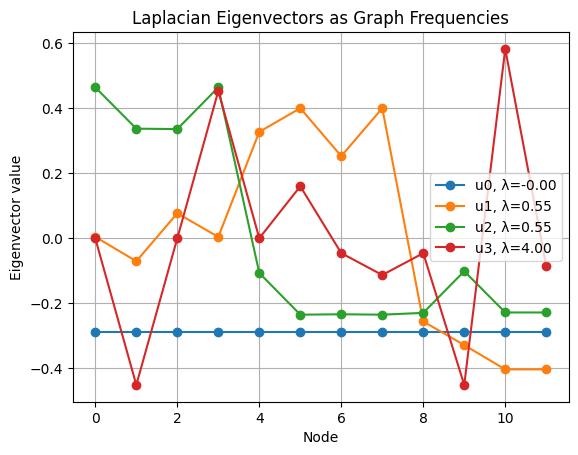

In [8]:
plt.figure()
for i in range(4):
    plt.plot(eigenvectors[:, i], marker="o", label=f"u{i}, λ={eigenvalues[i]:.2f}")
plt.title("Laplacian Eigenvectors as Graph Frequencies")
plt.xlabel("Node")
plt.ylabel("Eigenvector value")
plt.legend()
plt.grid(True)
plt.show()

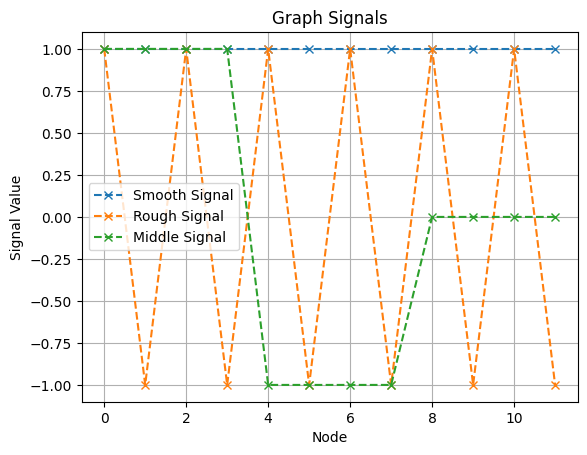

In [9]:
plt.plot(smooth_signal, marker="x", label="Smooth Signal", linestyle="--")
plt.plot(rough_signal, marker="x", label="Rough Signal", linestyle="--")
plt.plot(middle_signal, marker="x", label="Middle Signal", linestyle="--")
plt.title("Graph Signals")
plt.xlabel("Node")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)

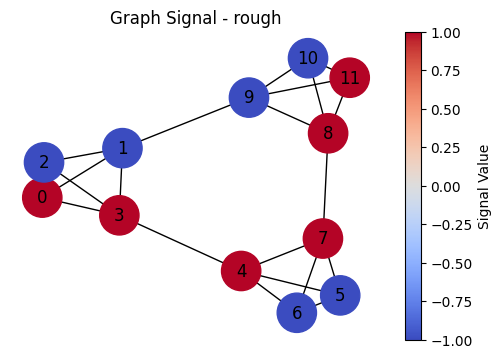

In [10]:
signals = [smooth_signal, rough_signal, middle_signal]
signal = signals[1]  # or signals[1] or signals[2]
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=800,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title(f"Graph Signal - {'smooth' if signal is smooth_signal else 'rough' if signal is rough_signal else 'middle'}")
plt.axis("off")
plt.show()

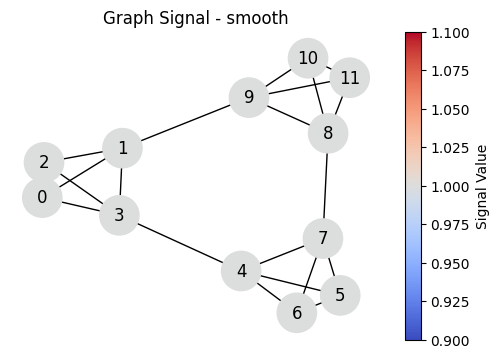

In [12]:
signals = [smooth_signal, rough_signal, middle_signal]
signal = signals[0]  # or signals[1] or signals[2]
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=800,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title(f"Graph Signal - {'smooth' if signal is smooth_signal else 'rough' if signal is rough_signal else 'middle'}")
plt.axis("off")
plt.show()

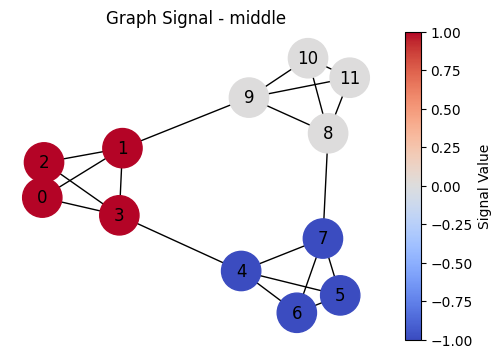

In [13]:
signals = [smooth_signal, rough_signal, middle_signal]
signal = signals[2]  # or signals[1] or signals[2]
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=800,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title(f"Graph Signal - {'smooth' if signal is smooth_signal else 'rough' if signal is rough_signal else 'middle'}")
plt.axis("off")
plt.show()

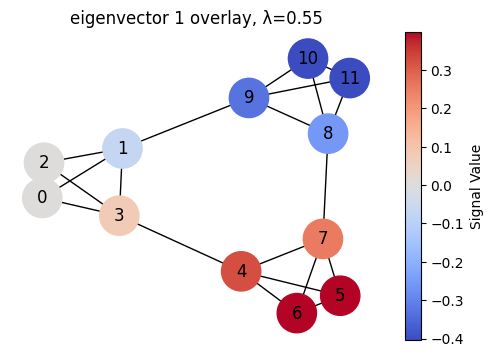

[ 0.00392186 -0.07083963  0.07652433  0.00392186  0.32696581  0.39956828
  0.25220431  0.39956828 -0.25612618 -0.32872865 -0.40349014 -0.40349014]


In [14]:
k = 1
signal = eigenvectors[:, k]
signal = np.round(signal, 10) 
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=800,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title(f"eigenvector {k} overlay, λ={eigenvalues[k]:.2f}")
plt.axis("off")
plt.show()
print(eigenvectors[:, k])

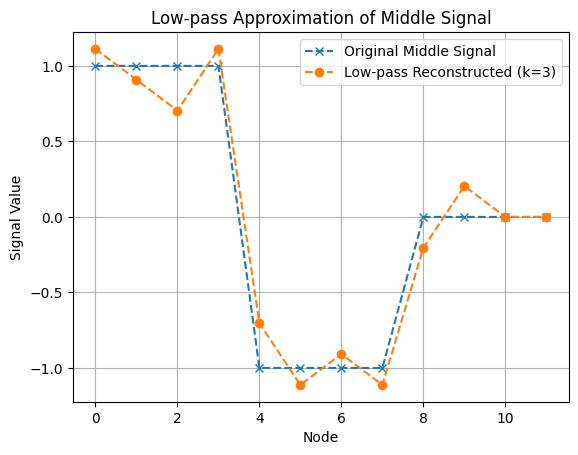

In [15]:
k = 3
U_low = eigenvectors[:, :k]
middle_hat_low = graph_fourier_transform(middle_signal, U_low)
middle_low_reconstructed = inverse_graph_fourier_transform(middle_hat_low, U_low)

plt.plot(middle_signal, marker="x", label="Original Middle Signal", linestyle="--")
plt.plot(middle_low_reconstructed, marker="o", label=f"Low-pass Reconstructed (k={k})", linestyle="--")
plt.title("Low-pass Approximation of Middle Signal")
plt.xlabel("Node")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.show()

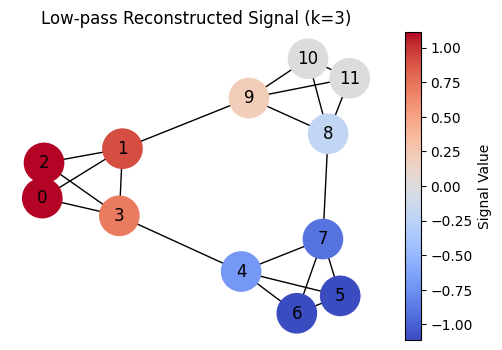

In [16]:
signal = middle_low_reconstructed
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=800,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title("Low-pass Reconstructed Signal (k=3)")
plt.axis("off")
plt.show()